# Atividade 4 — Pandas: crescimento populacional por estado e município (2010–2022)

Tabela usada: `CD2022_Populacao_2010_Compatibilizada_20231222_1.xlsx` (IBGE, População 2010 Compatibilizada).

In [1]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Abrir a tabela

In [2]:
path = r"C:\Users\LC\Downloads\CD2022_Populacao_2010_Compatibilizada_20231222 (1).xlsx"
df = pd.read_excel(path, engine="openpyxl", header=2)
df.columns

Index(['Unnamed: 0', 'UF', 'COD. UF', 'COD. MUNIC', 'NOME DO MUNICÍPIO',
       'População Município 2010\n(Sinopse)',
       'População 2010 (Alterações de Limites até 2022)1',
       'População Censo 2022'],
      dtype='str')

In [3]:
df.head()

,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0


## 2. Descobrir as colunas de UF, município e população

O nome exato das colunas pode variar conforme a planilha, então localizamos pelo padrão do nome em vez de digitar fixo.

In [4]:
colunas = list(df.columns)

col_cod_uf = [c for c in colunas if "cod" in str(c).lower() and "uf" in str(c).lower()][0]
col_uf = [c for c in colunas if c != col_cod_uf and ("uf" in str(c).lower() or "sigla" in str(c).lower())][0]
col_cod_mun = [c for c in colunas if "cod" in str(c).lower() and "munic" in str(c).lower()][0]
col_mun = [c for c in colunas if "munic" in str(c).lower() and "cod" not in str(c).lower()][0]
# População 2010 compatibilizada com os limites territoriais de 2022 (a própria planilha
# recomenda usar essa versão, e não a "Sinopse", para calcular crescimento até 2022)
col_2010 = [c for c in colunas if "2010" in str(c) and ("limit" in str(c).lower() or "altera" in str(c).lower())][0]
col_2022 = [c for c in colunas if "2022" in str(c) and "censo" in str(c).lower()][0]

col_cod_uf, col_uf, col_cod_mun, col_mun, col_2010, col_2022

('COD. UF',
 'UF',
 'COD. MUNIC',
 'NOME DO MUNICÍPIO',
 'População 2010 (Alterações de Limites até 2022)1',
 'População Censo 2022')

In [5]:
df[col_2010] = pd.to_numeric(df[col_2010], errors="coerce")
df[col_2022] = pd.to_numeric(df[col_2022], errors="coerce")

## 3. População agregada por estado

In [6]:
pop_estado = (
    df.groupby([col_cod_uf, col_uf], as_index=False)
    .agg(
        populacao_2010=(col_2010, "sum"),
        populacao_2022=(col_2022, "sum"),
    )
)
pop_estado

,COD. UF,UF,populacao_2010,populacao_2022
0,11.0,RO,1562409.0,1581196.0
1,12.0,AC,733559.0,830018.0
2,13.0,AM,3483985.0,3941613.0
3,14.0,RR,450479.0,636707.0
4,15.0,PA,7581051.0,8120131.0
5,16.0,AP,669526.0,733759.0
6,17.0,TO,1383445.0,1511460.0
7,21.0,MA,6574789.0,6776699.0
8,22.0,PI,3119097.0,3271199.0
9,23.0,CE,8451644.0,8794957.0


### Ordenar pelo crescimento entre 2010 e 2022

In [7]:
pop_estado["crescimento"] = pop_estado["populacao_2022"] - pop_estado["populacao_2010"]
pop_estado = pop_estado.sort_values("crescimento", ascending=False).reset_index(drop=True)
pop_estado

,COD. UF,UF,populacao_2010,populacao_2022,crescimento
0,35.0,SP,41262199.0,44411238.0,3149039.0
1,42.0,SC,6248436.0,7610361.0,1361925.0
2,52.0,GO,6001789.0,7056495.0,1054706.0
3,41.0,PR,10444526.0,11444380.0,999854.0
4,31.0,MG,19597330.0,20539989.0,942659.0
5,51.0,MT,3035122.0,3658649.0,623527.0
6,15.0,PA,7581051.0,8120131.0,539080.0
7,13.0,AM,3483985.0,3941613.0,457628.0
8,23.0,CE,8451644.0,8794957.0,343313.0
9,32.0,ES,3514952.0,3833712.0,318760.0


### Salvar em CSV

In [8]:
pop_estado.to_csv(r"C:\Users\LC\Desktop\cotemig_2026\Python\ATIVIDADE_AVALIATIVA_PANDAS\populacao_por_estado.csv", sep=";")

## 4. Agora por município

In [9]:
pop_municipio = (
    df.groupby([col_cod_mun, col_mun, col_uf], as_index=False)
    .agg(
        populacao_2010=(col_2010, "sum"),
        populacao_2022=(col_2022, "sum"),
    )
)
pop_municipio["crescimento"] = pop_municipio["populacao_2022"] - pop_municipio["populacao_2010"]
pop_municipio = pop_municipio.sort_values("crescimento", ascending=False).reset_index(drop=True)
pop_municipio

,COD. MUNIC,NOME DO MUNICÍPIO,UF,populacao_2010,populacao_2022,crescimento
0,2603.0,Manaus,AM,1802014.0,2063689.0,261675.0
1,108.0,Brasília,DF,2572159.0,2817381.0,245222.0
2,50308.0,São Paulo,SP,11253503.0,11451999.0,198496.0
3,52205.0,Sorocaba,SP,586816.0,723682.0,136866.0
4,8707.0,Goiânia,GO,1301912.0,1437366.0,135454.0
...,...,...,...,...,...,...
5565,14902.0,Porto Alegre,RS,1409351.0,1332845.0,-76506.0
5566,1402.0,Belém,PA,1393399.0,1303403.0,-89996.0
5567,4904.0,São Gonçalo,RJ,999728.0,896744.0,-102984.0
5568,4557.0,Rio de Janeiro,RJ,6320446.0,6211223.0,-109223.0


### Salvar em CSV

In [10]:
pop_municipio.to_csv(r"C:\Users\LC\Desktop\cotemig_2026\Python\ATIVIDADE_AVALIATIVA_PANDAS\populacao_por_municipio.csv", sep=";")

## 5. Gráfico: 10 estados que mais cresceram

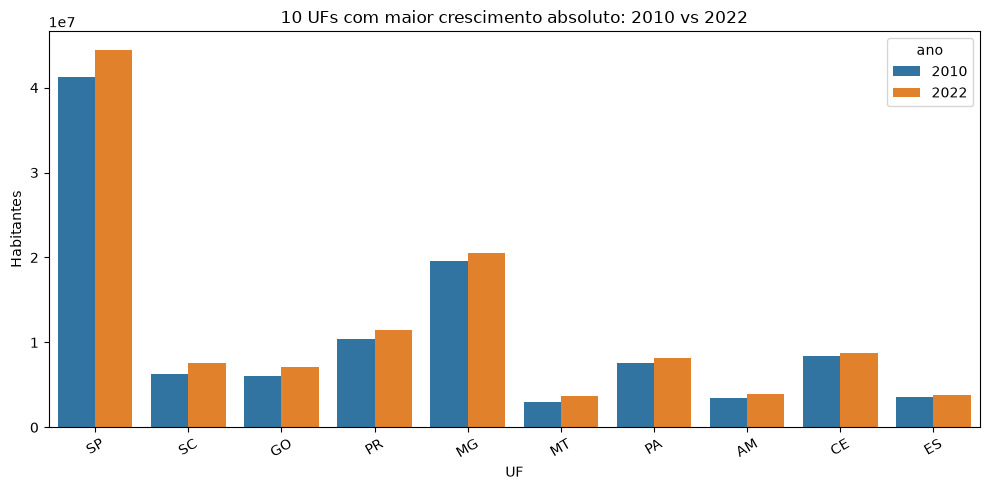

In [11]:
top = pop_estado.head(10).rename(columns={"populacao_2010": "2010", "populacao_2022": "2022"}).melt(
    id_vars=col_uf,
    value_vars=["2010", "2022"],
    var_name="ano",
    value_name="populacao",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x=col_uf, y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()